<a href="https://colab.research.google.com/github/WeaamGomaa/CNN-Architecture-Optimizers-Transfer-Learning/blob/main/Assignment2_CNN_Optimizers_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.src.backend.jax.nn import categorical_crossentropy
from rich import padding
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# Helper Function

In [ ]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Task 1

## 1A. Normalization Comparison

CNN Architecture

In [ ]:
def BaselineCNN():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

#### 1. Code for 3 experiments

Experiment A

In [ ]:
model_a = BaselineCNN()
history_a, test_acc_a, test_loss_a, time_a = train_and_evaluate(model_a, x_train, y_train, x_val, y_val, x_test, y_test)

Test Acc: 0.5281 | Test Loss: 2.8849 | Time:58.9


Experiment B

In [ ]:
x_train_minmax = x_train / 255.0
x_val_minmax = x_val / 255.0
x_test_minmax = x_test / 255.0

model_b = BaselineCNN()
history_b, test_acc_b, test_loss_b, time_b = train_and_evaluate(model_b, x_train_minmax, y_train, x_val_minmax, y_val, x_test_minmax, y_test)

Test Acc: 0.6547 | Test Loss: 1.4335 | Time:49.1


Experiment C

In [ ]:
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train_standardized = (x_train - mean) / std
x_val_standardized = (x_val - mean) / std
x_test_standardized = (x_test - mean) / std

model_c = BaselineCNN()
history_c, test_acc_c, test_loss_c, time_c = train_and_evaluate(model_c, x_train_standardized,y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Test Acc: 0.6742 | Test Loss: 2.1295 | Time:48.7


4. Results Table

In [ ]:
print("\nPreprocessing | Train Acc | Val Acc | Test Acc | Loss @ Epoch1")
print("-" * 55)
print(f"{'None (0-255)':<15} {history_a.history['accuracy'][-1]:<12.4f} {history_a.history['val_accuracy'][-1]:<12.4f} {test_acc_a:<12.4f} {history_a.history['loss'][0]:<12.4f}")
print(f"{'Min-Max [0,1]':<15} {history_b.history['accuracy'][-1]:<12.4f} {history_b.history['val_accuracy'][-1]:<12.4f} {test_acc_b:<12.4f} {history_b.history['loss'][0]:<12.4f}")
print(f"{'Standardized':<15} {history_c.history['accuracy'][-1]:<12.4f} {history_c.history['val_accuracy'][-1]:<12.4f} {test_acc_c:<12.4f} {history_c.history['loss'][0]:<12.4f}")


Preprocessing | Train Acc | Val Acc | Test Acc | Loss @ Epoch1
-------------------------------------------------------
None (0-255)    0.8895       0.5279       0.5281       4.1616      
Min-Max [0,1]   0.8902       0.6641       0.6547       1.5693      
Standardized    0.9769       0.6793       0.6742       1.3932      


2, 3. Visualization

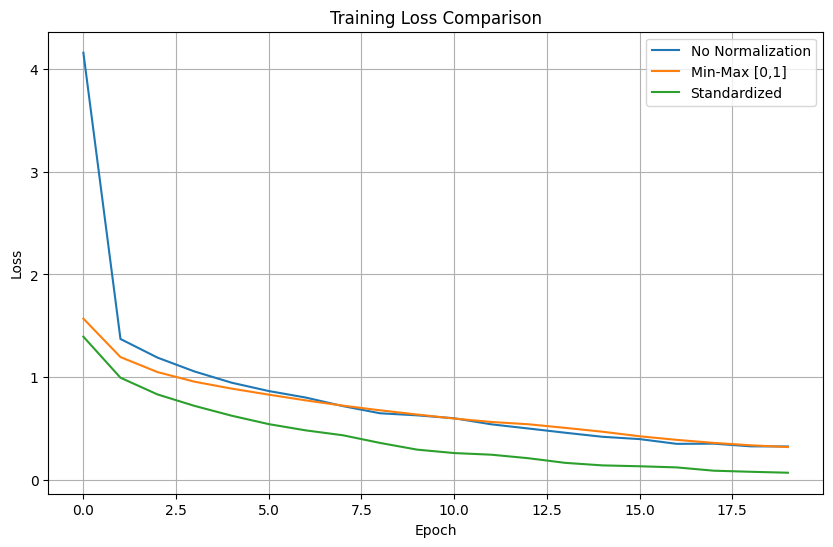

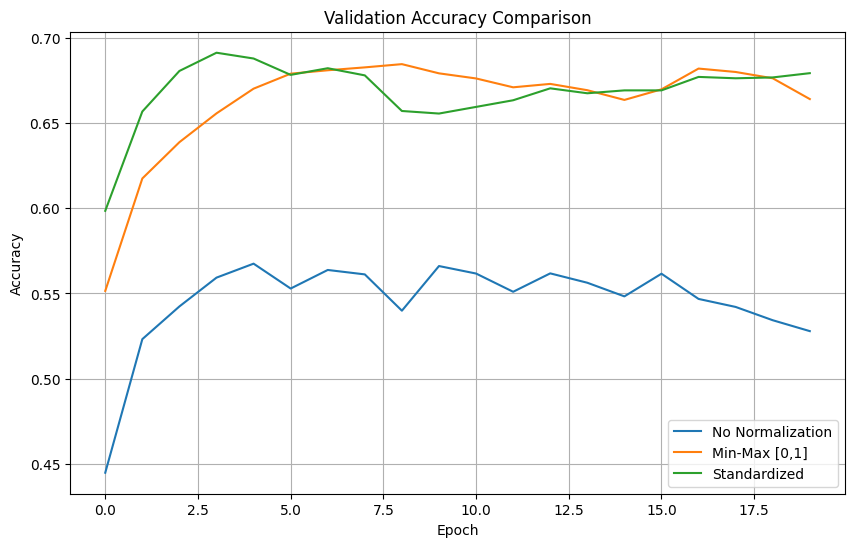

In [ ]:
histories = [history_a, history_b, history_c]
plot_curves(histories, labels=['No Normalization', 'Min-Max [0,1]', 'Standardized'],
            metric='loss',
            title='Training Loss Comparison',
            ylabel='Loss')
plot_curves(histories, labels=['No Normalization', 'Min-Max [0,1]', 'Standardized'],
            metric='val_accuracy',
            title='Validation Accuracy Comparison',
            ylabel='Accuracy')

## 1B. Data Augmentation Comparison

In [ ]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
    )
datagen.fit(x_train_standardized)

#### 5. Code for both experiments

Training BaslinCNN with Data Augmentation

In [ ]:
model_no_aug = BaselineCNN()
history_no_aug = model_no_aug.fit(
    x_train_standardized, to_categorical(y_train, 10),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=40,batch_size=128)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5098 - loss: 1.3840 - val_accuracy: 0.6013 - val_loss: 1.1388
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6553 - loss: 0.9907 - val_accuracy: 0.6681 - val_loss: 0.9679
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7104 - loss: 0.8362 - val_accuracy: 0.6819 - val_loss: 0.9291
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7487 - loss: 0.7278 - val_accuracy: 0.6998 - val_loss: 0.8880
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7798 - loss: 0.6370 - val_accuracy: 0.7032 - val_loss: 0.8938
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8055 - loss: 0.5641 - val_accuracy: 0.6880 - val_loss: 0.9730
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8274 - loss: 0.5058 - val_accuracy: 0.6729 - val_loss: 1.0577
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8384 - loss: 0.4647 - val_accuracy: 0

Training BaslinCNN without Data Augmentation


In [ ]:
model_aug = BaselineCNN()
history_aug = model_aug.fit(
    datagen.flow(x_train_standardized ,to_categorical(y_train, 10) ,batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=40)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.4524 - loss: 1.5329 - val_accuracy: 0.5908 - val_loss: 1.1718
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.5755 - loss: 1.2068 - val_accuracy: 0.6282 - val_loss: 1.0606
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.6139 - loss: 1.1001 - val_accuracy: 0.6655 - val_loss: 0.9725
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.6396 - loss: 1.0241 - val_accuracy: 0.6774 - val_loss: 0.9467
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6610 - loss: 0.9645 - val_accuracy: 0.6749 - val_loss: 0.9530
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6704 - loss: 0.9327 - val_accuracy: 0.6875 - val_loss: 0.9100
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6881 - loss: 0.8917 - val_accuracy: 0.7125 - val_loss: 0.8493
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.6979 - loss: 0.8638 - 

6. Visualization

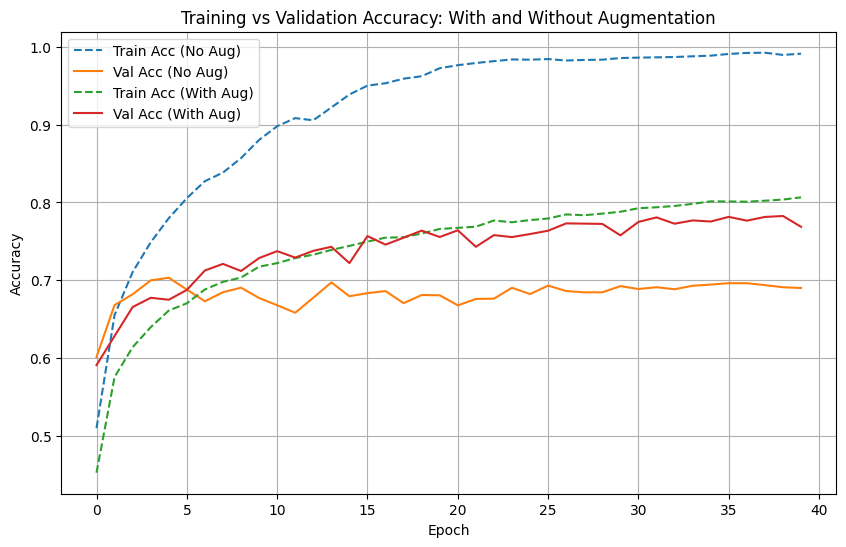

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)', linestyle='--')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (With Aug)', linestyle='--')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy: With and Without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

7. gap report

In [ ]:
# without augmentation
train_acc_no_aug = history_no_aug.history['accuracy'][-1]
val_acc_no_aug = history_no_aug.history['val_accuracy'][-1]
gap_no_aug = train_acc_no_aug - val_acc_no_aug

# with augmentation
train_acc_aug = history_aug.history['accuracy'][-1]
val_acc_aug = history_aug.history['val_accuracy'][-1]
gap_aug = train_acc_aug - val_acc_aug

print(f"Without Augmentation -- Train:{train_acc_no_aug:} -- Validation:{val_acc_no_aug:} -- Gap:{gap_no_aug:}")
print(f"With Augmentation -- Train:{train_acc_aug} -- Validation:{val_acc_aug:} -- Gap:{gap_aug:}")
print("Model with smaller gap overfits less:")
if gap_aug > gap_no_aug:
    print("Without Augmentation")
else:
    print("With Augmentation")


Without Augmentation -- Train:0.9913750290870667 -- Validation:0.6899999976158142 -- Gap:0.30137503147125244
With Augmentation -- Train:0.8065999746322632 -- Validation:0.7687000036239624 -- Gap:0.03789997100830078
Model with smaller gap overfits less:
With Augmentation


# Task 2

## 2A. Filter Count Comparison

CNN Architecture

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models

def build_cnn_filters(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

#### 8, 9. Code for 3 models, summary for each

Small Model

In [ ]:
small_model = build_cnn_filters(8, 8, 16, 16)
history_small, test_acc_small, test_loss_small, time_small = train_and_evaluate(small_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

small_model.summary()

Test Acc: 0.5908 | Test Loss: 2.6352 | Time:44.1


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807,800 (3.08 MB)

 Trainable params: 269,266 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 538,534 (2.05 MB)

Medium Model

In [ ]:
medium_model = build_cnn_filters(32, 32, 64, 64)
history_medium, test_acc_medium, test_loss_medium, time_medium = train_and_evaluate(medium_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

medium_model.summary()

Test Acc: 0.7218 | Test Loss: 2.1900 | Time:78.7


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,350,912 (12.78 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,233,942 (8.52 MB)

Large Model

In [ ]:
large_model = build_cnn_filters(64, 64, 128, 128)
history_large, test_acc_large, test_loss_large, time_large = train_and_evaluate(large_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

large_model.summary()

Test Acc: 0.7327 | Test Loss: 2.1182 | Time:149.1


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,080,416 (27.01 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,720,278 (18.01 MB)

10. Results Table

In [ ]:
print("\nModel | Total Params | Train Acc | Val Acc | Test Acc | Time")
print("-" * 70)
print(f"{'Small':<10} {small_model.count_params():<10} {history_small.history['accuracy'][-1]:<10.4f} {history_small.history['val_accuracy'][-1]:<10.4f} {test_acc_small:<10.4f} {time_small:<10.4f}")
print(f"{'Medium':<10} {medium_model.count_params():<10} {history_medium.history['accuracy'][-1]:<10.4f} {history_medium.history['val_accuracy'][-1]:<10.4f} {test_acc_medium:<10.4f} {time_medium:<10.4f}")
print(f"{'Large':<10} {large_model.count_params():<10} {history_large.history['accuracy'][-1]:<10.4f} {history_large.history['val_accuracy'][-1]:<10.4f} {test_acc_large:<10.4f} {time_large:<10.4f}")


Model | Total Params | Train Acc | Val Acc | Test Acc | Time
----------------------------------------------------------------------
Small      269266     0.9333     0.5883     0.5908     44.0979   
Medium     1116970    0.9890     0.7261     0.7218     78.6607   
Large      2360138    0.9869     0.7455     0.7327     149.1070  


11. Visualization

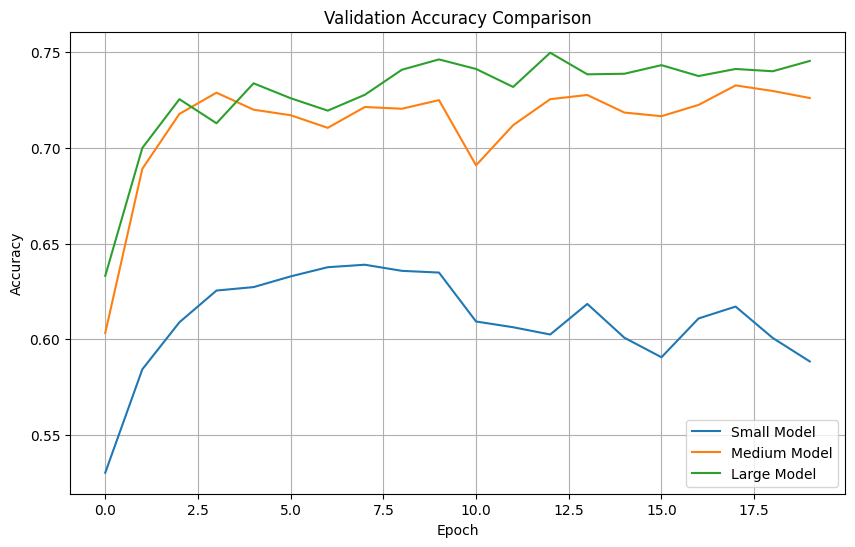

In [ ]:
histories = [history_small, history_medium, history_large]
plot_curves(histories, labels=['Small Model', 'Medium Model', 'Large Model'],
            metric='val_accuracy',
            title='Validation Accuracy Comparison',
            ylabel='Accuracy')

## 2B. Network Depth Comparison

CNN Architecture

In [ ]:
def build_cnn_depth(depth=''):
    if depth == 'Shallow':
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),

            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),

            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    elif depth == 'Medium':
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#-----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#--------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.GlobalAveragePooling2D(),

            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    elif depth == 'Deep':
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),
#----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D(pool_size=(2, 2)),

#----------------------------------------------------------------------
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.GlobalAveragePooling2D(),

            layers.Dense(256, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

#### 12. Code for 3 models

Shallow Model

In [ ]:
shallow_model = build_cnn_depth('Shallow')
history_shallow, test_acc_shallow, test_loss_shallow, time_shallow = train_and_evaluate(shallow_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Test Acc: 0.6962 | Test Loss: 2.3101 | Time:72.6


Medium Model

In [ ]:
medium_depth_model = build_cnn_depth('Medium')
history_medium_depth, test_acc_medium_depth, test_loss_medium_depth, time_medium_depth = train_and_evaluate(medium_depth_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Test Acc: 0.7341 | Test Loss: 0.7873 | Time:71.2


Deep Model

In [ ]:
deep_model = build_cnn_depth('Deep')
history_deep, test_acc_deep, test_loss_deep, time_deep = train_and_evaluate(deep_model, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test)

Test Acc: 0.7168 | Test Loss: 0.9271 | Time:75.1


13. Results Table

In [ ]:
print("\nModel | Total Params | Train Acc | Val Acc | Test Acc | Time")
print("-" * 70)
print(f"{'Shallow':<10} {shallow_model.count_params():<12.4f} {history_shallow.history['accuracy'][-1]:<10.4f} {history_shallow.history['val_accuracy'][-1]:<10.4f} {test_acc_shallow:<10.4f} {time_shallow:<10.4f}")
print(f"{'Medium':<10} {medium_depth_model.count_params():<12.4f} {history_medium_depth.history['accuracy'][-1]:<10.4f} {history_medium_depth.history['val_accuracy'][-1]:<10.4f} {test_acc_medium_depth:<10.4f} {time_medium_depth:<10.4f}")
print(f"{'Deep':<10} {deep_model.count_params():<12.4f} {history_deep.history['accuracy'][-1]:<10.4f} {history_deep.history['val_accuracy'][-1]:<10.4f} {test_acc_deep:<10.4f} {time_deep:<10.4f}")



Model | Total Params | Train Acc | Val Acc | Test Acc | Time
----------------------------------------------------------------------
Shallow    555754.0000  0.9811     0.7040     0.6962     72.5660   
Medium     58154.0000   0.7931     0.7417     0.7341     71.1950   
Deep       76650.0000   0.8289     0.7227     0.7168     75.0971   


14. Visualization

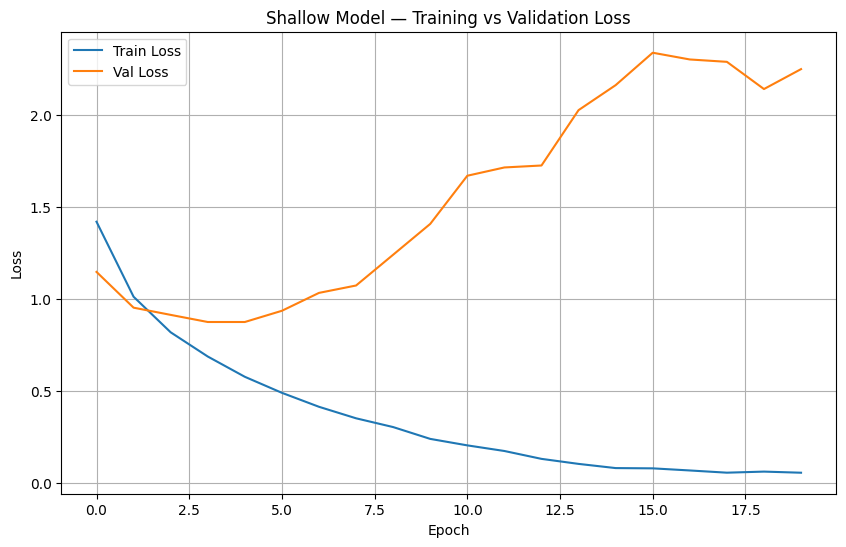

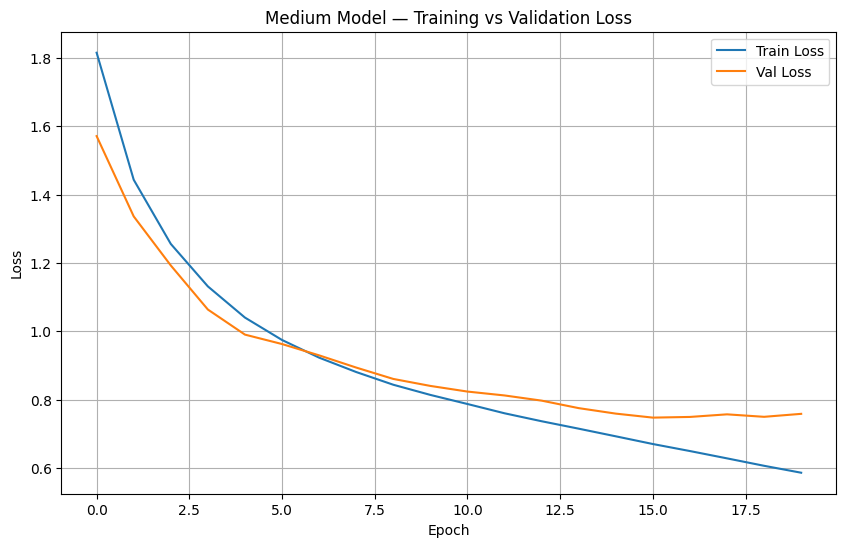

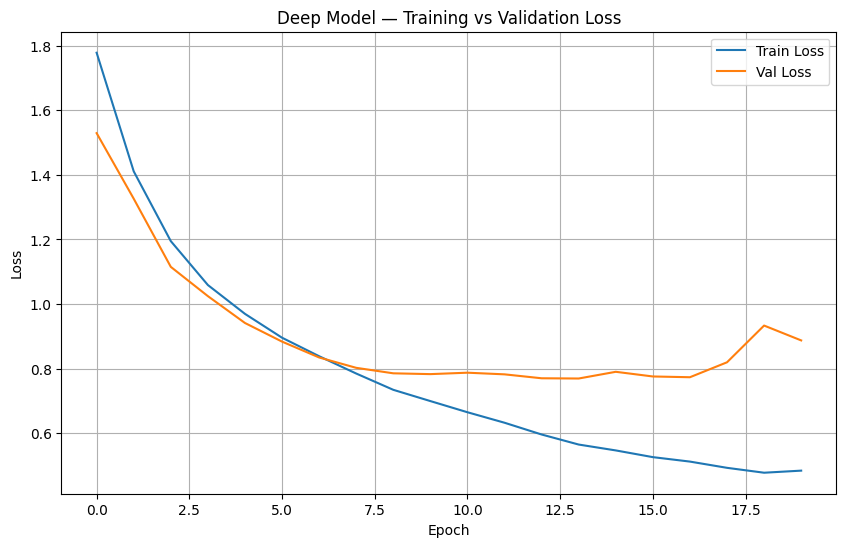

In [ ]:
histories = [history_shallow, history_medium_depth, history_deep]
model_names = ['Shallow', 'Medium', 'Deep']

for history, name in zip(histories, model_names):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{name} Model — Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Depth Report

In [ ]:
print("Medium depth model has the best performance")
print("Shallow model : doesn't have enough depth to learn complex and abstract features.")
print("Deep model : More layers = more parameters = more overfitting, and applying 3 MaxPool operations on 32x32 image makes the spatial dimensions become 4×4, which is extremely small for 8 conv layers to work with")

Medium depth model has the best performance
Shallow model : doesn't have enough depth to learn complex and abstract features.
Deep model : More layers = more parameters = more overfitting, and applying 3 MaxPool operations on 32x32 image makes the spatial dimensions become 4×4, which is extremely small for 8 conv layers to work with


# Task 3

## 3.A Dropout Rates Comparison



16, 17. Code for 3 models, overfit gap

In [ ]:
def build_dropout_model(rate):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(rate),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(rate),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(rate),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Train D0, D1, D2
rates = [0.0, 0.25, 0.5]
dropout_hist = []
dropout_results = []

for r in rates:
    print(f"Training model with dropout rate {r}")
    m = build_dropout_model(r)
    h, t_acc, t_loss, elapsed = train_and_evaluate(m, x_train_standardized, y_train, x_val_standardized, y_val, x_test_standardized, y_test, epochs = 30)

    dropout_hist.append(h)
    gap = h.history['accuracy'][-1] - h.history['val_accuracy'][-1]
    dropout_results.append([f"D{rates.index(r)}", h.history['accuracy'][-1], h.history['val_accuracy'][-1], t_acc, gap])

Training model with dropout rate 0.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7203 | Test Loss: 2.5463 | Time:112.0
Training model with dropout rate 0.25
Test Acc: 0.7761 | Test Loss: 0.8965 | Time:118.0
Training model with dropout rate 0.5
Test Acc: 0.7928 | Test Loss: 0.6062 | Time:116.6


18. Results Table

In [ ]:
print("\nModel | Train Acc | Val Acc | Test Acc | Overfit Gap")
print("-" * 55)
for res in dropout_results:
    print(f"{res[0]} | {res[1]:.4f} | {res[2]:.4f} | {res[3]:.4f} | {res[4]:.4f}")


Model | Train Acc | Val Acc | Test Acc | Overfit Gap
-------------------------------------------------------
D0 | 0.9861 | 0.7179 | 0.7203 | 0.2682
D1 | 0.9316 | 0.7759 | 0.7761 | 0.1557
D2 | 0.7932 | 0.8016 | 0.7928 | -0.0084


19, 20. Visualization

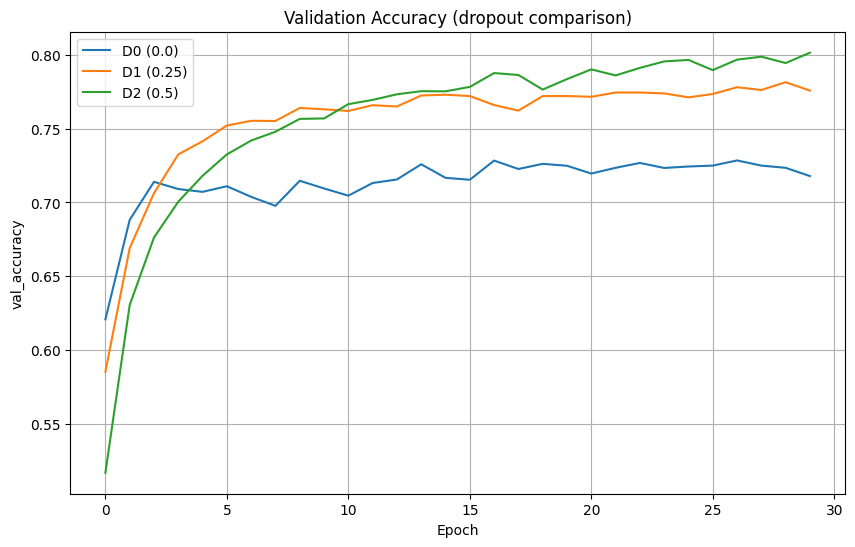

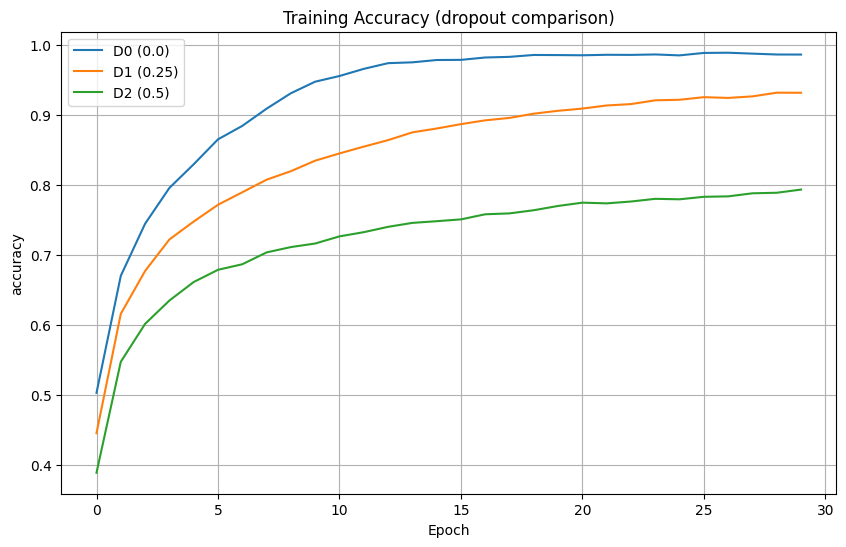

In [ ]:
plot_curves(dropout_hist, ['D0 (0.0)', 'D1 (0.25)', 'D2 (0.5)'], metric='val_accuracy', title='Validation Accuracy (dropout comparison)')
plot_curves(dropout_hist, ['D0 (0.0)', 'D1 (0.25)', 'D2 (0.5)'], metric='accuracy', title='Training Accuracy (dropout comparison)')

21. Best Test Accuracy & smallest overfit gap

In [ ]:
best_test_acc = max(dropout_results, key=lambda x: x[3])
smallest_overfit_gap = min(dropout_results, key=lambda x: x[4])

print(f"Best test accuracy: {best_test_acc[0]} (Accuracy: {best_test_acc[3]:.4f})")
print(f"Smallest overfit gap: {smallest_overfit_gap[0]} (Gap: {smallest_overfit_gap[4]:.4f})")

Best test accuracy: D2 (Accuracy: 0.7928)
Smallest overfit gap: D2 (Gap: -0.0084)


## 3.B Early Stopping Comparison

22. Code for 3 experiments

In [ ]:
es_configs = [
    {'name': 'ES0', 'callbacks': None,  'epochs': 50},
    {'name': 'ES2', 'callbacks': [callbacks.EarlyStopping(
        monitor='val_loss', patience=5,  restore_best_weights=True)], 'epochs': 50},
    {'name': 'ES3', 'callbacks': [callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True)], 'epochs': 50},
]
es_hist = []
es_results   = {}

for cfg in es_configs:
    print(f"\nRunning {cfg['name']}")
    m = build_dropout_model(0.0) # no dropout model

    h, t_acc, t_loss, elapsed = train_and_evaluate(
        m, x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=cfg['epochs'],
        extra_callbacks=cfg['callbacks']
    )

    es_hist.append(h) # store hist

    stopped_at = len(h.history['val_loss'])
    best_val_loss = min(h.history['val_loss'])
    es_results[cfg['name']] = {
        'stopped_at': stopped_at,
        'best_val_loss': best_val_loss,
        'test_acc': t_acc,
        'time': elapsed
    }



Running ES0
Test Acc: 0.6952 | Test Loss: 3.1012 | Time:185.7

Running ES2
Test Acc: 0.7079 | Test Loss: 0.8752 | Time:39.1

Running ES3
Test Acc: 0.7086 | Test Loss: 0.8520 | Time:52.9


23. Results Table

In [ ]:
print(f"{'Experiment':<12} {'Stopped At':>10} {'Best Val Loss':>14} {'Test Acc':>10} {'Time (s)':>10}")
for name, res in es_results.items():
    print(f"{name:<12} {res['stopped_at']:>10} {res['best_val_loss']:>14.4f} {res['test_acc']:>10.4f} {res['time']:>10.1f}")

Experiment   Stopped At  Best Val Loss   Test Acc   Time (s)
ES0                  50         0.8982     0.6952      185.7
ES2                   9         0.8360     0.7079       39.1
ES3                  13         0.8358     0.7086       52.9


24. Visualization

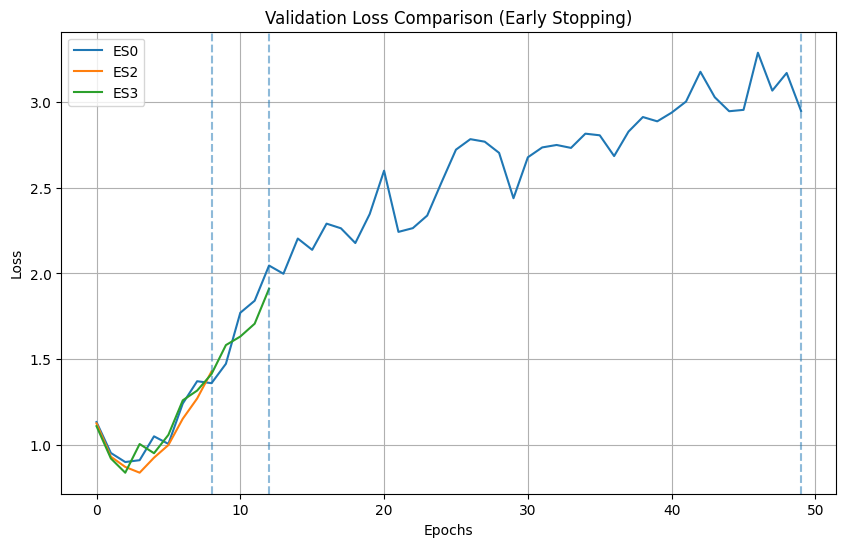

In [ ]:
plt.figure(figsize=(10, 6))
for h, cfg in zip(es_hist, es_configs):
    plt.plot(h.history['val_loss'], label=cfg['name'])
    plt.axvline(x=len(h.history['val_loss'])-1, linestyle='--', alpha=0.5) # mark stopping pt with vertical line

plt.title("Validation Loss Comparison (Early Stopping)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

25.
Patience 5 is aggressive, where it stopped at epoch 8 and gave an accuracy of 69.54%.

Patience 10 is not too lenient, where it stopped at epoch 13 and gave an accuracy of 71.05% which is very similar to the 50 epoch accuracy (71.87%)


# Task 4

## 4.A Optimizer Comparison (same learning rate)

26. code for 5 runs

In [ ]:
optimizers = {
'SGD': keras.optimizers.SGD(learning_rate=0.001),
'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

opt_results = []
opt_hist = []

for name, opt in optimizers.items():
  print(f"Training with optimizer {name}")
  m = build_dropout_model(0.0)
  m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

  h, t_acc, t_loss, elapsed = train_and_evaluate(
        m, x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test, epochs=30
        )

  opt_hist.append(h)
  opt_results.append([
      name, h.history['loss'][-1],
      h.history['val_loss'][-1],
      t_acc,
      elapsed
  ])

Training with optimizer SGD
Test Acc: 0.5214 | Test Loss: 1.3485 | Time:111.6
Training with optimizer Momentum
Test Acc: 0.6344 | Test Loss: 1.4034 | Time:113.2
Training with optimizer AdaGrad
Test Acc: 0.5696 | Test Loss: 1.2182 | Time:114.2
Training with optimizer RMSProp
Test Acc: 0.7200 | Test Loss: 3.6344 | Time:109.8
Training with optimizer Adam
Test Acc: 0.7224 | Test Loss: 2.3989 | Time:111.8


27. Results Table

In [ ]:
print(f"{'Optimizer':<12} {'Train Loss':>12} {'Val Loss':>12} {'Test Acc':>10} {'Time (s)':>10}")
print("-" * 60)

for res in opt_results:
    print(f"{res[0]:<12} {res[1]:>12.4f} {res[2]:>12.4f} {res[3]:>10.4f} {res[4]:>10.1f}")

Optimizer      Train Loss     Val Loss   Test Acc   Time (s)
------------------------------------------------------------
SGD                1.3101       1.3641     0.5214      111.6
Momentum           0.3476       1.3772     0.6344      113.2
AdaGrad            1.1190       1.2237     0.5696      114.2
RMSProp            0.0354       3.5870     0.7200      109.8
Adam               0.0427       2.3220     0.7224      111.8


28, 29. Visualization

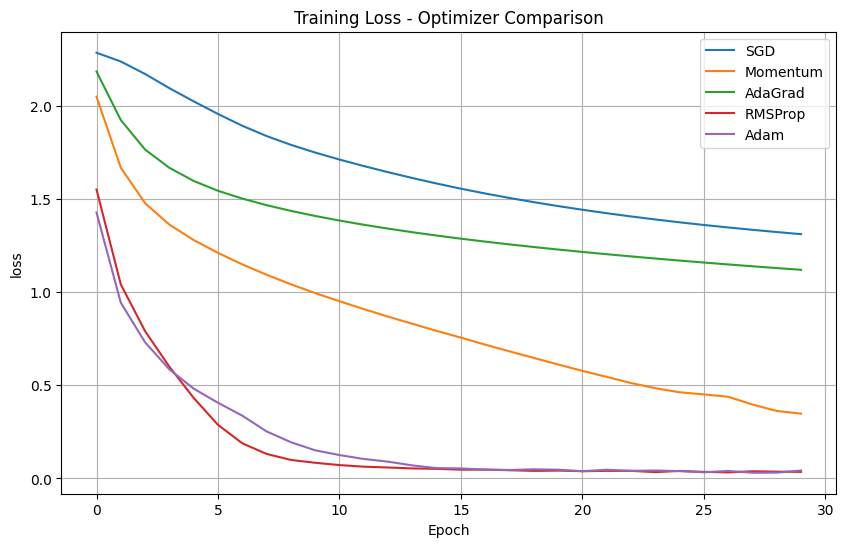

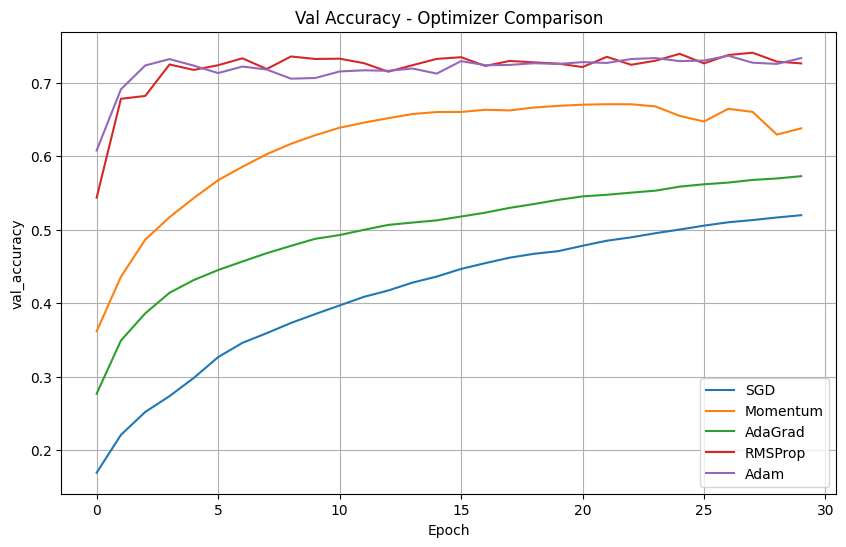

In [ ]:
plot_curves(opt_hist, list(optimizers.keys()), metric='loss', title='Training Loss - Optimizer Comparison')
plot_curves(opt_hist, list(optimizers.keys()), metric='val_accuracy', title='Val Accuracy - Optimizer Comparison')

30. Adam converges fastest (reaches val_acc > 0.65 first)

## 4.B learning rate sensitivity (Adam)

31. code for 3 runs

In [ ]:
learning_rates = [0.0001, 0.001, 0.01]
lr_results = []
lr_hist = []

for lr in learning_rates:
  print(f"Training Adam with learning rate {lr}")

  m = build_dropout_model(0.0)
  m.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  h, t_acc, t_loss, elapsed = train_and_evaluate(
      m, x_train_standardized, y_train,
      x_val_standardized, y_val,
      x_test_standardized, y_test, epochs=30
  )

  lr_hist.append(h)
  lr_results.append([lr, h.history['loss'][-1], h.history['val_loss'][-1], t_acc])

Training Adam with learning rate 0.0001
Test Acc: 0.6589 | Test Loss: 1.4173 | Time:117.5
Training Adam with learning rate 0.001
Test Acc: 0.7208 | Test Loss: 2.4814 | Time:116.2
Training Adam with learning rate 0.01
Test Acc: 0.4683 | Test Loss: 2.3811 | Time:111.2


32. Results Table

In [ ]:
print(f"{'LR':<10} {'Train Loss':>12} {'Val Loss':>12} {'Test Acc':>10}")
print("-" * 48)

for res in lr_results:
    print(f"{str(res[0]):<10} {res[1]:>12.4f} {res[2]:>12.4f} {res[3]:>10.4f}")

LR           Train Loss     Val Loss   Test Acc
------------------------------------------------
0.0001           0.2215       1.3780     0.6589
0.001            0.0325       2.4369     0.7208
0.01             0.7701       2.4124     0.4683


33, 34. Visualization

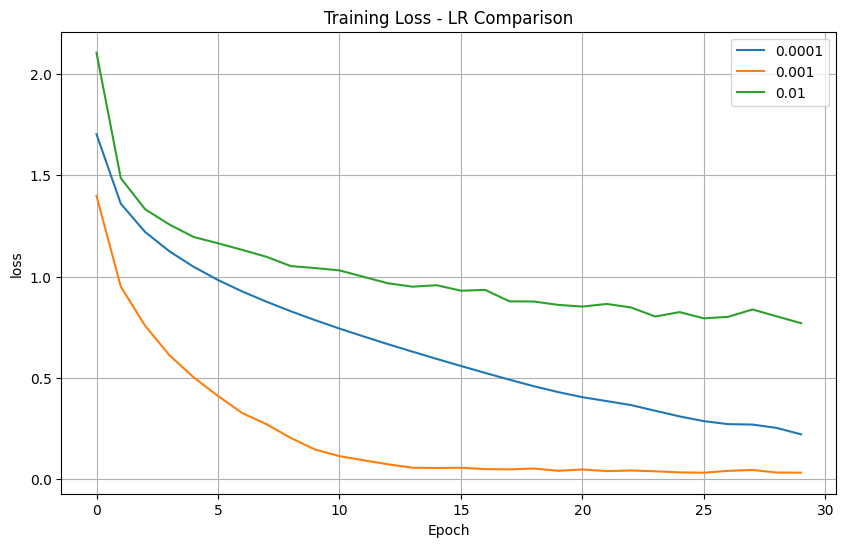

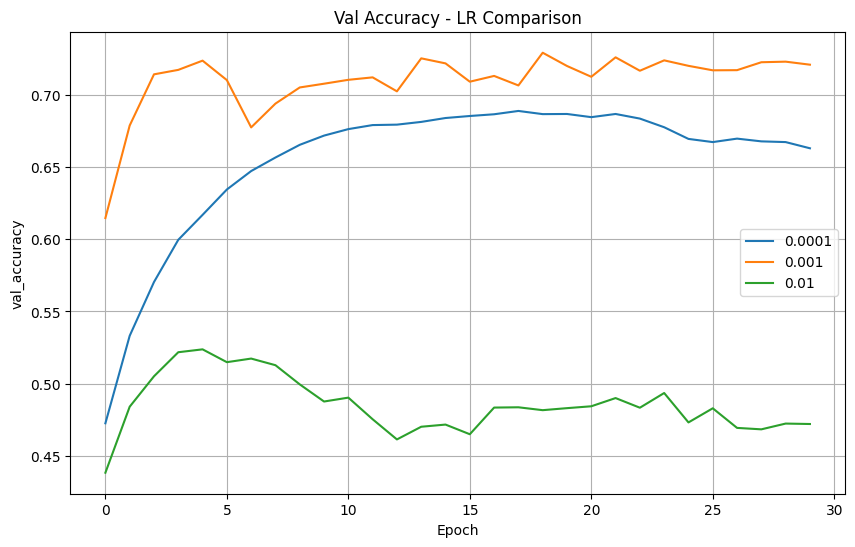

In [ ]:
plot_curves(lr_hist, [str(l) for l in learning_rates], metric='loss', title='Training Loss - LR Comparison')
plot_curves(lr_hist, [str(l) for l in learning_rates], metric='val_accuracy', title='Val Accuracy - LR Comparison')

35.
Too slow lr -> 0.0001

Unstable lr -> 0.01

Best lr -> 0.001

# Task 5

## 5.A Performance Evaluation

Best Params:
1. Standardization
2. Augmentation
3. filter count: Large
4. Depth: Medium
5. Dropout = 0.5
6. Early stopping, patience = 10
7. Adam Optimizer, Learning rate = 0.001

In [ ]:
# Normalization
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train_standardized = (x_train - mean) / std
x_val_standardized = (x_val - mean) / std
x_test_standardized = (x_test - mean) / std

In [ ]:
# Data Augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
    )

x_aug, y_aug = next(datagen.flow(x_train_standardized ,y_train, batch_size=128))

x_train_new = np.concatenate([x_train_standardized, x_aug], axis=0)
y_train_new = np.concatenate([y_train, y_aug], axis=0)

In [ ]:
# Build Best CNN
def build_best_model():
    model = models.Sequential([
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.5),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.5),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.5),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
best_model = build_best_model()

history_best,test_acc_best, test_loss_best, time_best = train_and_evaluate(best_model, x_train_new, y_train_new, x_val_standardized, y_val, x_test_standardized, y_test, epochs=50,
                                                                           extra_callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

best_model.summary()

Test Acc: 0.8183 | Test Loss: 0.5401 | Time:386.9


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,247,328 (12.39 MB)

 Trainable params: 1,082,442 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,164,886 (8.26 MB)

In [ ]:
import joblib

joblib.dump((mean, std), "standard.pkl")

['standard.pkl']

In [ ]:
best_model.save('best_model.keras')

37, 38. accuracy, confusion matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


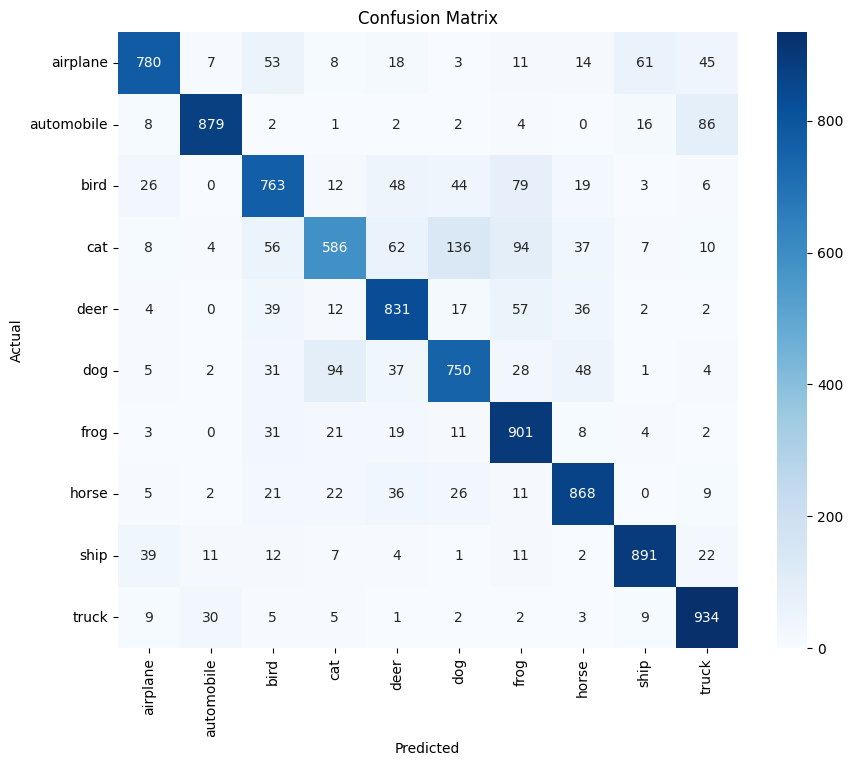

              precision    recall  f1-score   support

    airplane       0.88      0.78      0.83      1000
  automobile       0.94      0.88      0.91      1000
        bird       0.75      0.76      0.76      1000
         cat       0.76      0.59      0.66      1000
        deer       0.79      0.83      0.81      1000
         dog       0.76      0.75      0.75      1000
        frog       0.75      0.90      0.82      1000
       horse       0.84      0.87      0.85      1000
        ship       0.90      0.89      0.89      1000
       truck       0.83      0.93      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [ ]:
y_pred = np.argmax(best_model.predict(x_test_standardized), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

## 5.B Error Analysis

In [ ]:
misclassified_idx = np.where(y_pred != y_test.flatten())[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")

def show_misclassified(true_class, n=5):
  idx = [i for i in misclassified_idx if y_test[i] == true_class][:n]
  fig, axes = plt.subplots(1, n, figsize=(15, 3))
  for ax, i in zip(axes, idx):
    ax.imshow(x_test[i].astype('uint8'))
    ax.set_title(f"True: {CLASS_NAMES[y_test[i][0]]}\nPred: {CLASS_NAMES[y_pred[i]]}")
    ax.axis('off')
  plt.suptitle(f"Misclassified '{CLASS_NAMES[true_class]}'")
  plt.tight_layout()
  plt.show()

Total misclassified: 1817 / 10000


39, 40. 3 worst performing classes, 5 misclassified for each

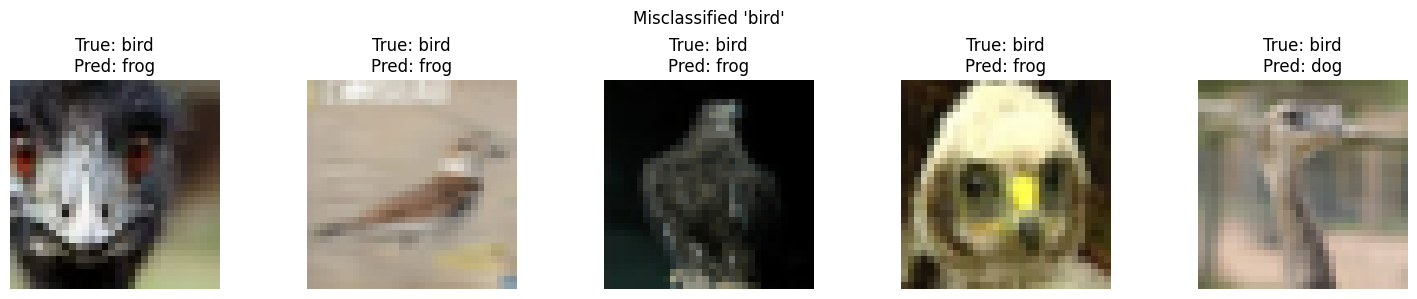

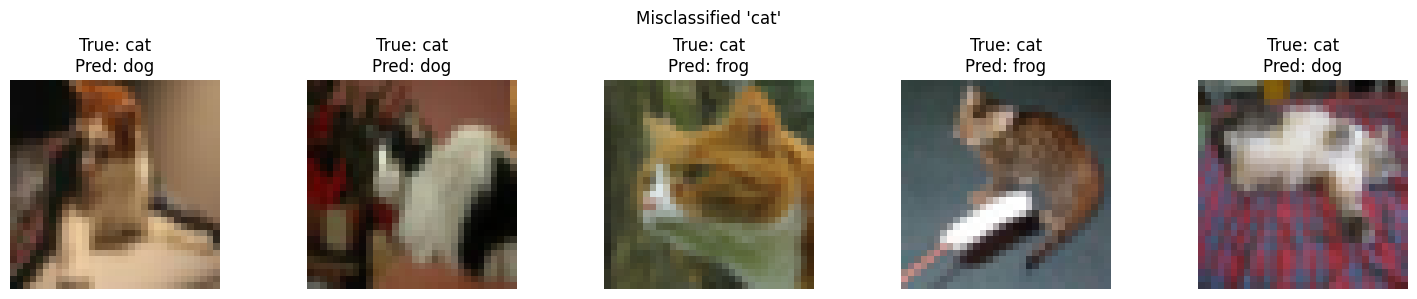

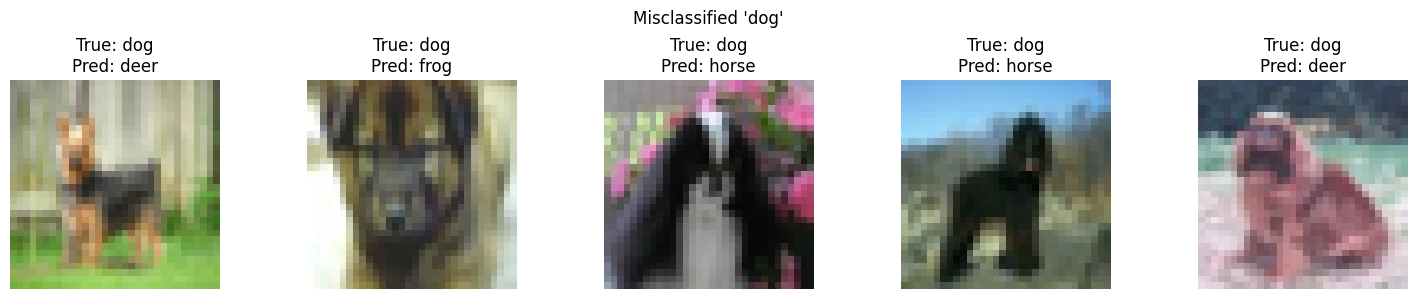

In [ ]:
show_misclassified(2)
show_misclassified(3)
show_misclassified(5)

41. 3 most confused class pairs and 4 examples from each

In [ ]:
# find the top 3 missclassified pairs from confusion matrix
pairs = []

for i in range(10):
  for j in range(i, 10):
    if i != j:
      pairs.append((cm[i, j] + cm[j, i], cm[i, j], cm[j, i], i, j))  # (total miss, miss i, miss j, class i, class j)

pairs.sort()

top_3 = pairs[-3:]
top_3.reverse()

print("Top 3 missclassified pairs:")
for total, miss_i, miss_j, i, j in top_3:
  print(f"Class {i} ({CLASS_NAMES[i]}) and Class {j} ({CLASS_NAMES[j]}), (Total Miss: {total}), (Miss {CLASS_NAMES[i]}: {miss_i}, Miss {CLASS_NAMES[j]}: {miss_j})")


Top 3 missclassified pairs:
Class 3 (cat) and Class 5 (dog), (Total Miss: 230), (Miss cat: 136, Miss dog: 94)
Class 1 (automobile) and Class 9 (truck), (Total Miss: 116), (Miss automobile: 86, Miss truck: 30)
Class 3 (cat) and Class 6 (frog), (Total Miss: 115), (Miss cat: 94, Miss frog: 21)


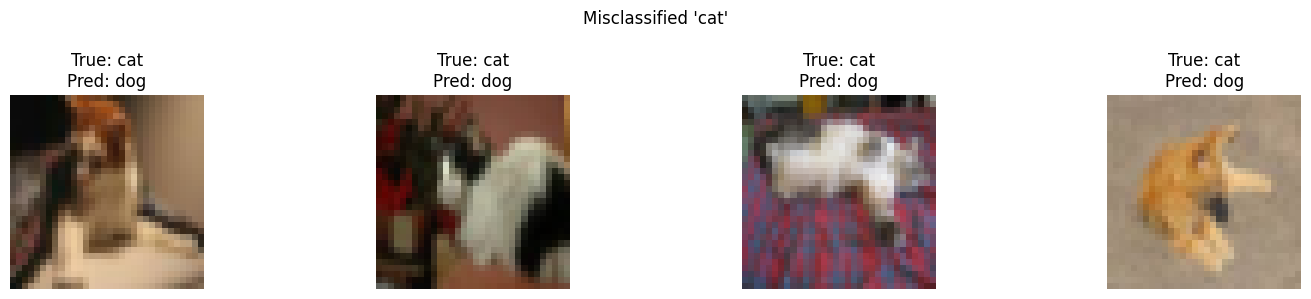

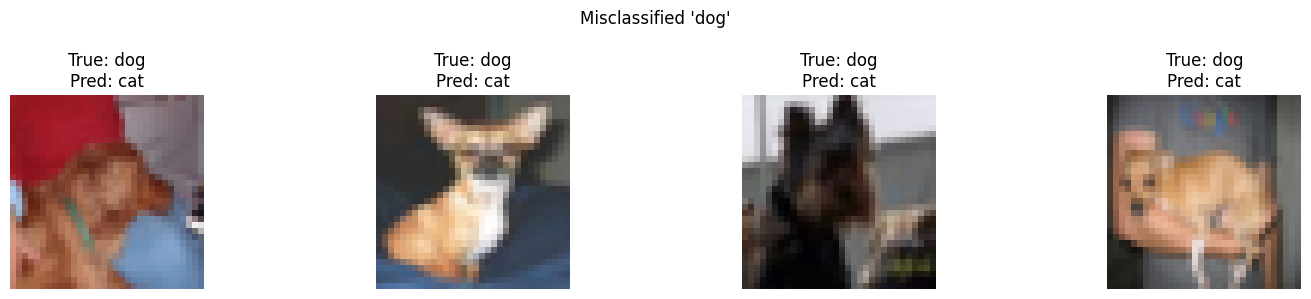

In [ ]:
# show missclassified examples for cat <-> dog
misclassified_idx = np.where((y_test.flatten() == 3) & (y_pred == 5) | (y_test.flatten() == 5) & (y_pred == 3))[0]
show_misclassified(3, 4)
show_misclassified(5, 4)

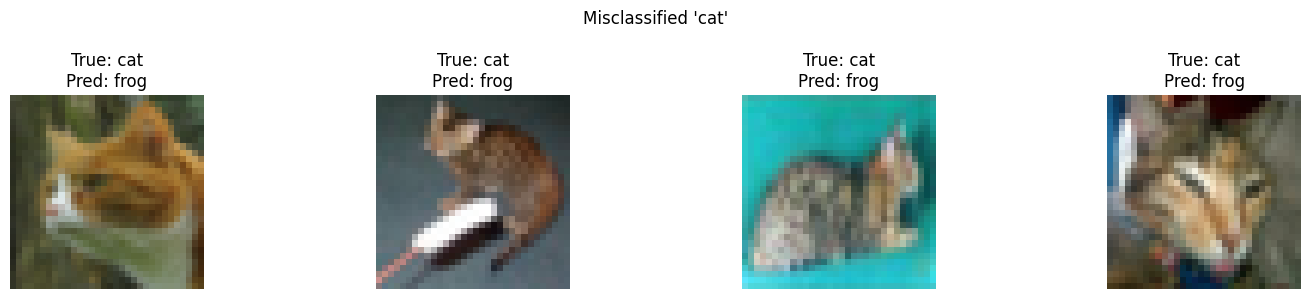

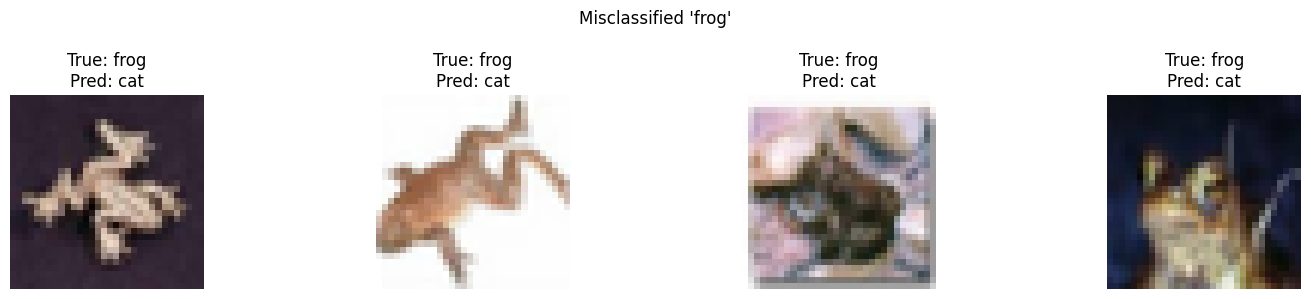

In [ ]:
# show missclassified examples for cat <-> frog
misclassified_idx = np.where((y_test.flatten() == 3) & (y_pred == 6) | (y_test.flatten() == 6) & (y_pred == 3))[0]
show_misclassified(3, 4)
show_misclassified(6, 4)

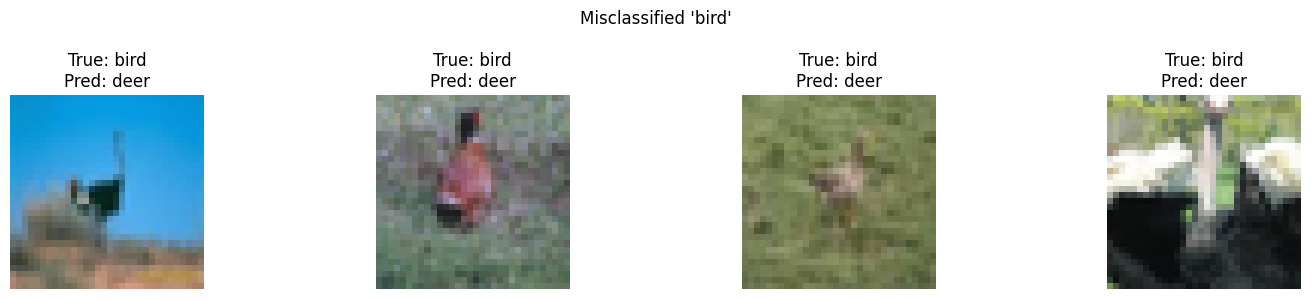

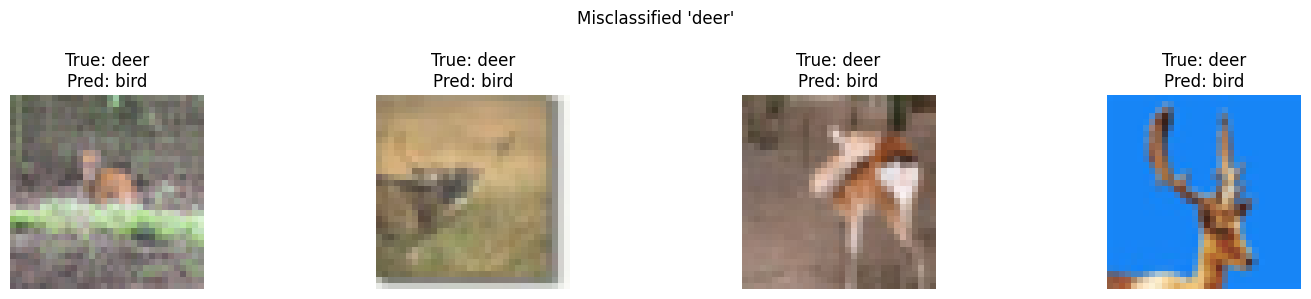

In [ ]:
# show missclassified examples for bird <-> deer
misclassified_idx = np.where((y_test.flatten() == 2) & (y_pred == 4) | (y_test.flatten() == 4) & (y_pred == 2))[0]
show_misclassified(2, 4)
show_misclassified(4, 4)

42. Why where they missclassified?

the missclassified images were similar in overall shape and color to other classes and the low resolution made it hard to distinguish

# Task 6

In [ ]:
from tensorflow.keras.applications import VGG16

## Resize Features

In [ ]:
x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized   = tf.image.resize(x_val_standardized,   (48, 48)).numpy()
x_test_resized  = tf.image.resize(x_test_standardized,  (48, 48)).numpy()

43, 44. Code for 4 models, model summary

## Model 1: From Scratch

In [ ]:
model1 = build_cnn_depth('Medium')
history_model1,test_acc_model1, test_loss_model1, time_model1 = train_and_evaluate(model1, x_train_resized, y_train, x_val_resized, y_val, x_test_resized, y_test)

model1.summary()

Test Acc: 0.7248 | Test Loss: 0.7818 | Time:135.1


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_102 (Conv2D)             │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_103 (Conv2D)             │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_104 (Conv2D)             │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_105 (Conv2D)             │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_106 (Conv2D)             │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_107 (Conv2D)             │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,464 (681.50 KB)

 Trainable params: 58,154 (227.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 116,310 (454.34 KB)

## Model 2: Feature Extraction

In [ ]:
# Load model and freeze layers
frozen_model = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
for layer in frozen_model.layers:
    layer.trainable = False

# Add classification head
x = layers.Flatten()(frozen_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(10, activation='softmax')(x)

# compile
model2 = models.Model(inputs=frozen_model.input, outputs=output)
model2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
history_model2,test_acc_model2, test_loss_model2, time_model2 = train_and_evaluate(model2, x_train_resized, y_train, x_val_resized, y_val, x_test_resized, y_test)

model2.summary()

Test Acc: 0.6958 | Test Loss: 0.9030 | Time:377.3


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,116,384 (57.66 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 267,798 (1.02 MB)

## Model 3: Fine Tuning (Partial Unfreeze)

In [ ]:
partial_frozen = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
for layer in partial_frozen.layers[:-4]:
  layer.trainable = False

# Add classification head
x = layers.Flatten()(partial_frozen.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(10, activation='softmax')(x)

# compile
model3 = models.Model(inputs=partial_frozen.input, outputs=output)
model3.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
history_model3,test_acc_model3, test_loss_model3, time_model3 = train_and_evaluate(model3, x_train_resized, y_train, x_val_resized, y_val, x_test_resized, y_test)

model3.summary()

Test Acc: 0.8243 | Test Loss: 0.5505 | Time:433.7


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,275,232 (111.68 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

## Model 4: Fine Tuning (Higher Learning Rate)

In [ ]:
#compile
model4 = models.Model(inputs=partial_frozen.input, outputs=output)
model4.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
history_model4,test_acc_model4, test_loss_model4, time_model4 = train_and_evaluate(model4, x_train_resized, y_train, x_val_resized, y_val, x_test_resized, y_test)

model4.summary()

Test Acc: 0.1000 | Test Loss: 2.3026 | Time:426.0


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,275,232 (111.68 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

45. results table

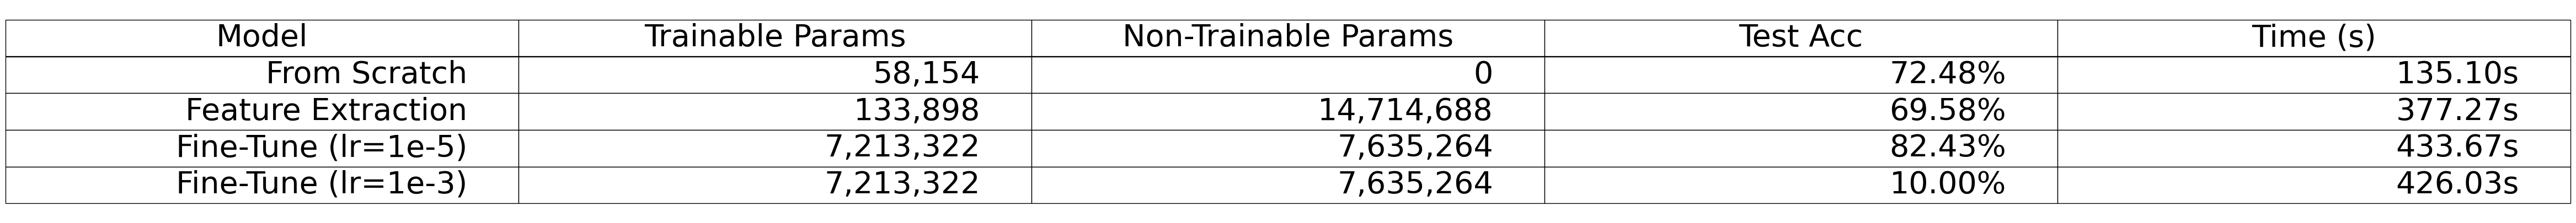

In [ ]:
summary = [
    ["From Scratch", "58,154", "0", f"{test_acc_model1*100:.2f}%", f"{time_model1:.2f}s"],
    ["Feature Extraction", "133,898", "14,714,688", f"{test_acc_model2*100:.2f}%", f"{time_model2:.2f}s"],
    ["Fine-Tune (lr=1e-5)", "7,213,322", "7,635,264", f"{test_acc_model3*100:.2f}%", f"{time_model3:.2f}s"],
    ["Fine-Tune (lr=1e-3)", "7,213,322", "7,635,264", f"{test_acc_model4*100:.2f}%", f"{time_model4:.2f}s"]
]

columns = ["Model", "Trainable Params", "Non-Trainable Params", "Test Acc", "Time (s)"]

fig, ax = plt.subplots(figsize=(20, 5))
ax.axis('off')  # hide axes

table = ax.table(cellText=summary, colLabels=columns, loc='center')

table.auto_set_font_size(False)
table.set_fontsize(40)
table.scale(3, 4)

plt.show()

### 46, 47. Visualization

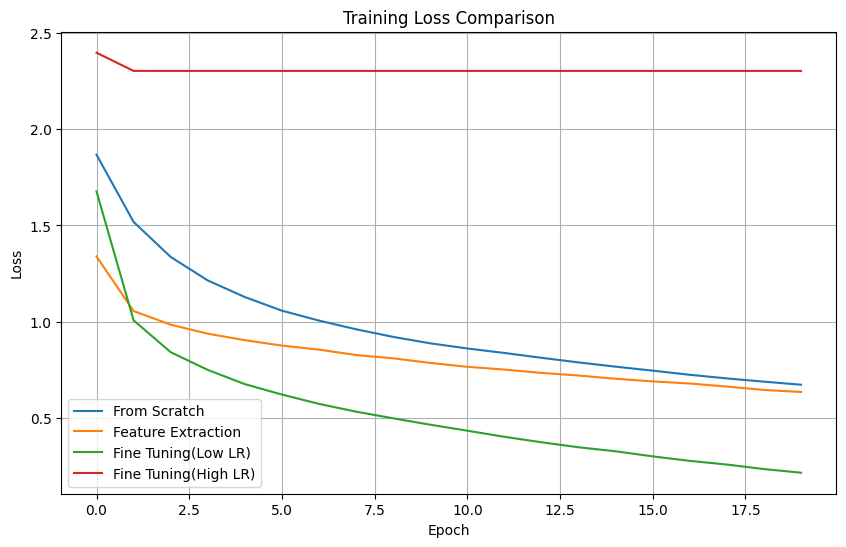

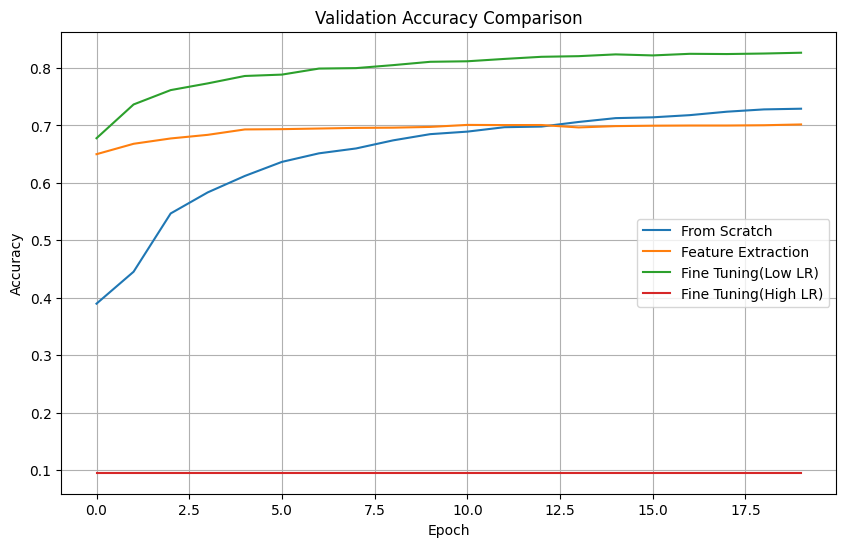

In [ ]:
labels = ['From Scratch', 'Feature Extraction', 'Fine Tuning(Low LR)', 'Fine Tuning(High LR)']
histories = [history_model1, history_model2, history_model3, history_model4]

plot_curves(histories, labels=labels,
            metric='loss',
            title='Training Loss Comparison',
            ylabel='Loss')
plot_curves(histories, labels=labels,
            metric='val_accuracy',
            title='Validation Accuracy Comparison',
            ylabel='Accuracy')

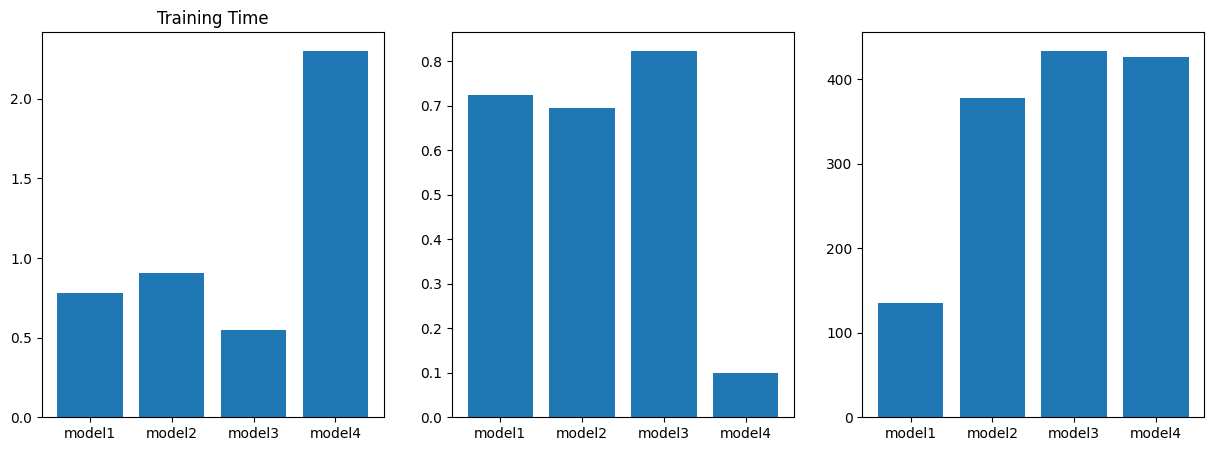

In [ ]:
labels = ['model1', 'model2', 'model3', 'model4']
test_loss = [test_loss_model1, test_loss_model2, test_loss_model3, test_loss_model4]
test_acc = [test_acc_model1, test_acc_model2, test_acc_model3, test_acc_model4]
time = [time_model1, time_model2, time_model3, time_model4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(labels, test_loss)
axes[0].set_title('Test Loss')

axes[1].bar(labels, test_acc)
axes[0].set_title('Test Accuracy')

axes[2].bar(labels, time)
axes[0].set_title('Training Time')

plt.show()

48. Model 3 outperforms Model 4 because the higher learning rate of Model 4 changes the pretrained weights too much.

49. transfer learning outperforms training from scratch because it was already trained to recognize the basics, so providing it with more data will yield better results than a model that doesn't know anything.

In [ ]:
model3.save('fine_tuning_model.keras')